In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# packages

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/heart_disease_risk_dataset_earlymed.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (70000, 19)


In [14]:
# data preprocessing

df = df.dropna()

target_column = "Heart_Risk"

X = df.drop(columns=[target_column])
y = df[target_column]

training_columns = X.columns.tolist()

In [15]:
# split data

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [16]:
# train model

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [17]:
# evaluation

train_acc = accuracy_score(y_train, model.predict(X_train))
val_acc = accuracy_score(y_val, model.predict(X_val))
test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

print("\n===== RESULTS =====")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))



===== RESULTS =====
Training Accuracy   : 0.9446
Validation Accuracy : 0.9389
Test Accuracy       : 0.9375
Precision           : 0.9332
Recall              : 0.9424
F1 Score            : 0.9378

Classification Report:

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94      7000
         1.0       0.93      0.94      0.94      7000

    accuracy                           0.94     14000
   macro avg       0.94      0.94      0.94     14000
weighted avg       0.94      0.94      0.94     14000



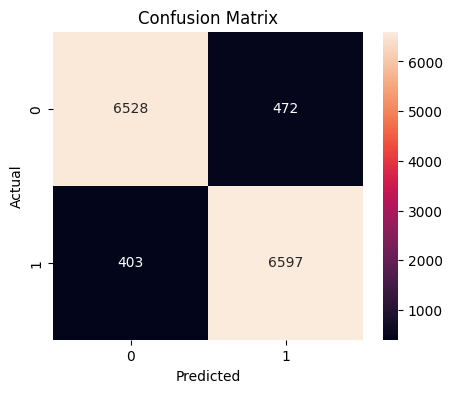

In [18]:
# confusion matrix

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
joblib.dump(model, "decision_tree_model.pkl")
joblib.dump(training_columns, "columns.pkl")

print("\nModel saved successfully.")


Model saved successfully.


In [20]:
# mannual test

manual_input = {
    'Chest_Pain': 1,
    'Shortness_of_Breath': 1,
    'Fatigue': 0,
    'Palpitations': 0,
    'Dizziness': 0,
    'Swelling': 0,
    'Pain_Arms_Jaw_Back': 0,
    'Cold_Sweats_Nausea': 1,
    'High_BP': 1,
    'High_Cholesterol': 1,
    'Diabetes': 1,
    'Smoking': 1,
    'Obesity': 0,
    'Sedentary_Lifestyle': 1,
    'Family_History': 1,
    'Chronic_Stress': 1,
    'Gender': 0,
    'Age': 60
}

input_df = pd.DataFrame([manual_input])

# Ensure column order
input_df = input_df[training_columns]

# Predict
prediction = model.predict(input_df)[0]
probability = model.predict_proba(input_df)[0][1]

print("\n===== MANUAL TEST =====")
print("Prediction:", "Heart Disease" if prediction == 1 else "No Heart Disease")
print(f"Probability: {probability:.4f}")


===== MANUAL TEST =====
Prediction: Heart Disease
Probability: 0.8373
